In [6]:
import numpy as np

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

def sigmoid_derivative(a):
    return a * (1.0 - a)

def forward_pass(X, W1, b1, W2, b2, W3, b3):
    Z1 = X @ W1 + b1
    A1 = sigmoid(Z1)
    
    Z2 = A1 @ W2 + b2
    A2 = sigmoid(Z2)
    
    Z3 = A2 @ W3 + b3
    A3 = sigmoid(Z3)
    
    return Z1, A1, Z2, A2, Z3, A3

def mse_loss(Y_true, Y_pred):
    return np.mean((Y_true - Y_pred) ** 2)

def backpropagation(X, Y_true, Z1, A1, Z2, A2, Z3, A3, W1, W2, W3):
    m = X.shape[0]
    
    delta3 = -2 * (Y_true - A3) * sigmoid_derivative(A3)
    dW3 = (A2.T @ delta3) / m
    db3 = np.sum(delta3, axis=0, keepdims=True) / m
    
    delta2 = (delta3 @ W3.T) * sigmoid_derivative(A2)
    dW2 = (A1.T @ delta2) / m
    db2 = np.sum(delta2, axis=0, keepdims=True) / m
    
    delta1 = (delta2 @ W2.T) * sigmoid_derivative(A1)
    dW1 = (X.T @ delta1) / m
    db1 = np.sum(delta1, axis=0, keepdims=True) / m
    
    return dW1, db1, dW2, db2, dW3, db3

def update_weights(W1, b1, W2, b2, W3, b3, dW1, db1, dW2, db2, dW3, db3, learning_rate):
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    W3 -= learning_rate * dW3
    b3 -= learning_rate * db3
    
    return W1, b1, W2, b2, W3, b3

In [7]:
import os
import urllib.request
import numpy as np

#  Download the dataset automatically if it's not already here
file_name = 'mnist.npz'
if not os.path.exists(file_name):
    print("Downloading MNIST dataset. This might take a few seconds...")
    url = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz"
    urllib.request.urlretrieve(url, file_name)
    print("Download complete!")

# 2. Load the data
data = np.load(file_name)

X_train = data['x_train'].reshape(-1, 784) / 255.0
Y_train = data['y_train']
X_test = data['x_test'].reshape(-1, 784) / 255.0
Y_test = data['y_test']

# 3. One-hot encode the labels
Y_train_oh = np.zeros((Y_train.size, 10))
Y_train_oh[np.arange(Y_train.size), Y_train] = 1

Y_test_oh = np.zeros((Y_test.size, 10))
Y_test_oh[np.arange(Y_test.size), Y_test] = 1

# 4. Initialize random weights
np.random.seed(42)
W1 = np.random.rand(784, 128) - 0.5
b1 = np.zeros((1, 128))

W2 = np.random.rand(128, 64) - 0.5
b2 = np.zeros((1, 64))

W3 = np.random.rand(64, 10) - 0.5
b3 = np.zeros((1, 10))

print("Data loaded and weights initialized!")

Download complete!
Data loaded and weights initialized!


In [8]:
learning_rate = 0.1
epochs = 20
batch_size = 32
loss_history = []

for epoch in range(epochs):
    idx = np.random.permutation(X_train.shape[0])
    X_shuf = X_train[idx]
    Y_shuf = Y_train_oh[idx]
    
    for start in range(0, X_train.shape[0], batch_size):
        X_batch = X_shuf[start : start + batch_size]
        Y_batch = Y_shuf[start : start + batch_size]
        
        Z1, A1, Z2, A2, Z3, A3 = forward_pass(X_batch, W1, b1, W2, b2, W3, b3)
        
        dW1, db1, dW2, db2, dW3, db3 = backpropagation(
            X_batch, Y_batch, Z1, A1, Z2, A2, Z3, A3, W1, W2, W3
        )
        
        W1, b1, W2, b2, W3, b3 = update_weights(
            W1, b1, W2, b2, W3, b3, dW1, db1, dW2, db2, dW3, db3, learning_rate
        )
        
    _, _, _, _, _, A3_full = forward_pass(X_train, W1, b1, W2, b2, W3, b3)
    epoch_loss = mse_loss(Y_train_oh, A3_full)
    loss_history.append(epoch_loss)
    print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.4f}")

Epoch 1/20 - Loss: 0.0296
Epoch 2/20 - Loss: 0.0208
Epoch 3/20 - Loss: 0.0172
Epoch 4/20 - Loss: 0.0153
Epoch 5/20 - Loss: 0.0138
Epoch 6/20 - Loss: 0.0127
Epoch 7/20 - Loss: 0.0119
Epoch 8/20 - Loss: 0.0111
Epoch 9/20 - Loss: 0.0105
Epoch 10/20 - Loss: 0.0100
Epoch 11/20 - Loss: 0.0095
Epoch 12/20 - Loss: 0.0091
Epoch 13/20 - Loss: 0.0088
Epoch 14/20 - Loss: 0.0084
Epoch 15/20 - Loss: 0.0081
Epoch 16/20 - Loss: 0.0078
Epoch 17/20 - Loss: 0.0076
Epoch 18/20 - Loss: 0.0073
Epoch 19/20 - Loss: 0.0071
Epoch 20/20 - Loss: 0.0069


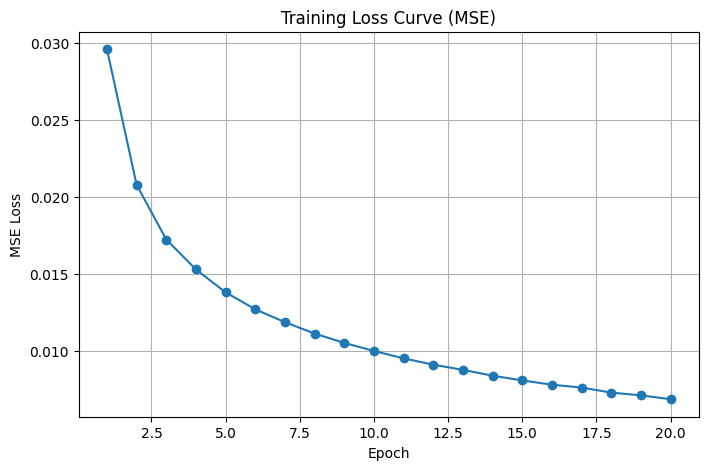

Final Test Accuracy: 95.54%


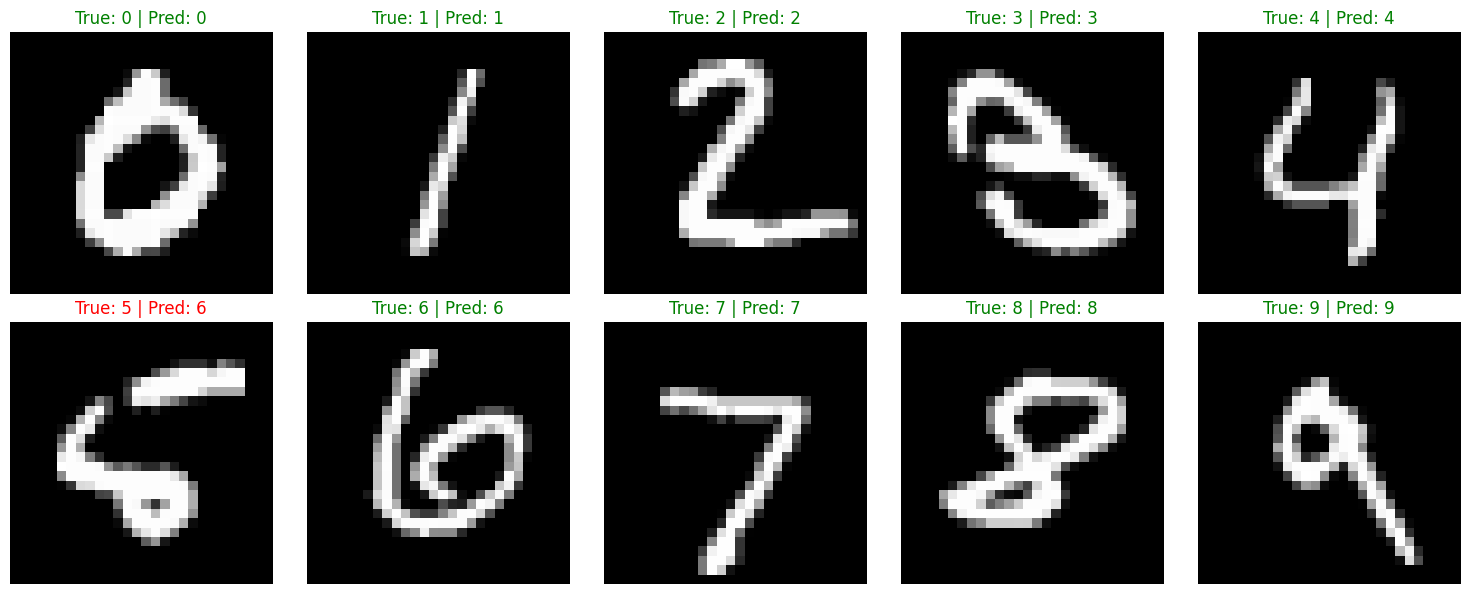

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), loss_history, marker='o')
plt.title("Training Loss Curve (MSE)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()

_, _, _, _, _, A3_test = forward_pass(X_test, W1, b1, W2, b2, W3, b3)
predictions = np.argmax(A3_test, axis=1)
accuracy = np.mean(predictions == Y_test) * 100
print(f"Final Test Accuracy: {accuracy:.2f}%")

plt.figure(figsize=(15, 6))
for i in range(10):
    idx = np.where(Y_test == i)[0][0]
    
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    pred_label = predictions[idx]
    
    plt.title(f"True: {i} | Pred: {pred_label}", 
              color='green' if i == pred_label else 'red')
    plt.axis('off')
    
plt.tight_layout()
plt.show()